# Exploratory Data Analysis
### Location: in (India)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
#visualization parameters
sns.set_theme(style='whitegrid')

In [3]:
#target IP to readable label mapping
TARGET_LABEL = {
    '8.8.8.8' : 'Google DNS (8.8.8.8)',
    '1.1.1.1' : 'Cloudflare DNS (1.1.1.1)',
    '94.140.14.14' : 'AdGuard DNS (94.140.14.14)',
    '185.222.222.222' : 'DNS.SB Europe (185.222.222.222)',
    '45.11.45.11' : 'DNS.SB Europe (45.11.45.11)'
}

ANALYZE_PROTOCOL = ['tcp', 'icmp', 'udp']

In [4]:
    #load dataset
active_df = pd.read_csv('../data/raw/active_probe_raw_2026_08_w3.csv')
passive_df = pd.read_csv('../data/raw/passive_probe_raw_2026_08_w3.csv')

In [5]:
#parse timestamp
active_df['timestamp'] = pd.to_datetime(active_df['timestamp'])
passive_df['timestamp'] = pd.to_datetime(passive_df['timestamp'])

In [6]:
print(f"Active Probe shape: {active_df.shape}")
print(f"Passive Probe shape: {passive_df.shape}\n")
print(f"Collection Period: {active_df.timestamp.min()} -> {active_df.timestamp.max()}")

Active Probe shape: (51300, 11)
Passive Probe shape: (977552, 11)

Collection Period: 2026-08-10 04:13:03 -> 2026-08-16 12:38:50


In [7]:
print("Active Probe INFO:")
active_df.info()

print("\nPassive Probe INFO:")
passive_df.info()

Active Probe INFO:
<class 'pandas.DataFrame'>
RangeIndex: 51300 entries, 0 to 51299
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        51300 non-null  datetime64[us]
 1   experiment_id    51300 non-null  str           
 2   source_location  51300 non-null  str           
 3   protocol         51300 non-null  str           
 4   dst_ip           51300 non-null  str           
 5   packet_size      51300 non-null  int64         
 6   probe_index      51300 non-null  int64         
 7   success          51300 non-null  bool          
 8   rtt_ms           36291 non-null  float64       
 9   send_timestamp   51300 non-null  float64       
 10  recv_timestamp   36291 non-null  float64       
dtypes: bool(1), datetime64[us](1), float64(3), int64(2), str(4)
memory usage: 4.0 MB

Passive Probe INFO:
<class 'pandas.DataFrame'>
RangeIndex: 977552 entries, 0 to 977551
Data columns (total 

In [8]:
print("Missing Values - ACTIVE: ")
print(active_df.isnull().sum())

print("\nMissing Values - PASSIVE: ")
print(passive_df.isnull().sum())

Missing Values - ACTIVE: 
timestamp              0
experiment_id          0
source_location        0
protocol               0
dst_ip                 0
packet_size            0
probe_index            0
success                0
rtt_ms             15009
send_timestamp         0
recv_timestamp     15009
dtype: int64

Missing Values - PASSIVE: 
timestamp                    0
src_ip                       0
dst_ip                       0
protocol                     0
packet_length                0
ttl                          0
tcp_flag                743717
window_size             743717
source_location              0
experiment_id                0
experiment_timestamp         0
dtype: int64


**Comment**: `rtt_ms`, `recv_timestamp` null in active probe is expected and they correspond to the failed probes (timeout).
`tcp_flag`, `window_size` null in passive probes is expected as these fields exist only for TCP packet.

### ACTIVE CAPTURE 

In [9]:
print("Experiment Coverage: ")
print(f"Protocols: {active_df.protocol.unique().tolist()}")
print(f"Packet Size: {sorted(active_df.packet_size.unique().tolist())}")
print(f"Target: {active_df.dst_ip.unique().tolist()}")
print(f"Location: {active_df.source_location.unique().tolist()}")
print(f"\nTotal Experiment: {active_df.experiment_id.nunique()}")
print(f"Probes per Experiment: {active_df.groupby('experiment_id').size().unique().tolist()}")

Experiment Coverage: 
Protocols: ['tcp', 'icmp', 'udp']
Packet Size: [64, 128, 256, 512, 1024, 1400]
Target: ['8.8.8.8', '1.1.1.1', '94.140.14.14', '185.222.222.222', '45.11.45.11']
Location: ['in']

Total Experiment: 1710
Probes per Experiment: [30]


In [10]:
success_summary = active_df.groupby('protocol')['success'].agg(
    total='count',
    successful='sum',
    success_rate='mean'
).round(4)
success_summary['success_rate'] = (success_summary['success_rate'] * 100).round(2).astype(str) + "%"
print(success_summary)

          total  successful success_rate
protocol                                
icmp      17100       16604        97.1%
tcp       17100        8876       51.91%
udp       17100       10811       63.22%


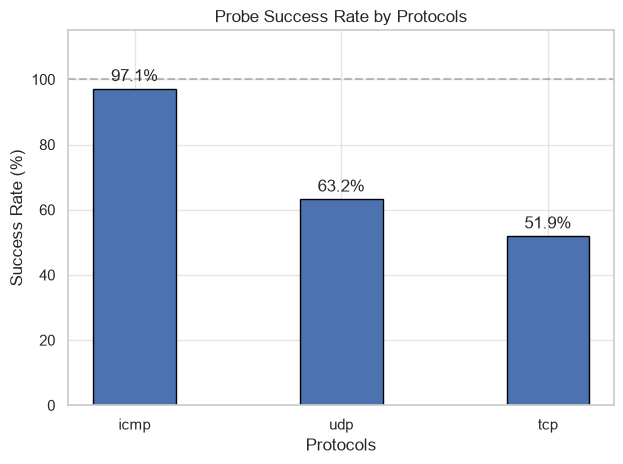

In [11]:
fig, ax = plt.subplots()
protocols = ["icmp", "udp", "tcp"]
success_rates = [
    active_df[active_df.protocol == 'icmp']['success'].mean() * 100,
    active_df[active_df.protocol == 'udp']['success'].mean() * 100,
    active_df[active_df.protocol == 'tcp']['success'].mean() * 100
]

bar = ax.bar(protocols, success_rates, edgecolor='black', width=0.4)
ax.bar_label(bar, fmt='%.1f%%', padding=3)
ax.set_ylim(0, 115)
ax.set_title("Probe Success Rate by Protocols")
ax.set_ylabel("Success Rate (%)")
ax.set_xlabel("Protocols")
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()

Unlike Singapore (0% TCP success - network level block), India shows Tcp succeeding 51.91% of the time. This confirms that the TCP raw SYN probing is not blocked on this network. ICMP remains the most reliable at 97.1% success. UDP sits at 63.22%, lower than in Singapore (73%).

In [12]:
success_df = active_df[(active_df['success'] == True) & (active_df['protocol'].isin(ANALYZE_PROTOCOL))].copy()
print(f"Clean successful probes: {len(success_df)}")
print(success_df.protocol.value_counts())

Clean successful probes: 36291
protocol
icmp    16604
udp     10811
tcp      8876
Name: count, dtype: int64


In [13]:
zero_rtt = success_df[success_df['rtt_ms'] == 0]
outliers = success_df[success_df['rtt_ms'] > 500]

print(f"Zero RTT rows: {len(zero_rtt)} ({len(zero_rtt)/len(success_df)*100:.1f}% of successful probes)")
print(f"Outliers >500ms: {len(outliers)} ({len(outliers)/len(success_df)*100:.1f}% of successful probes)")
print("\nZero RTT by protocol: ")
print(zero_rtt.groupby('protocol').size())
print("\nOutliers by protocol: ")
print(outliers.groupby('protocol').size())

Zero RTT rows: 6894 (19.0% of successful probes)
Outliers >500ms: 515 (1.4% of successful probes)

Zero RTT by protocol: 
protocol
icmp    2371
tcp     3830
udp      693
dtype: int64

Outliers by protocol: 
protocol
icmp     21
tcp     484
udp      10
dtype: int64


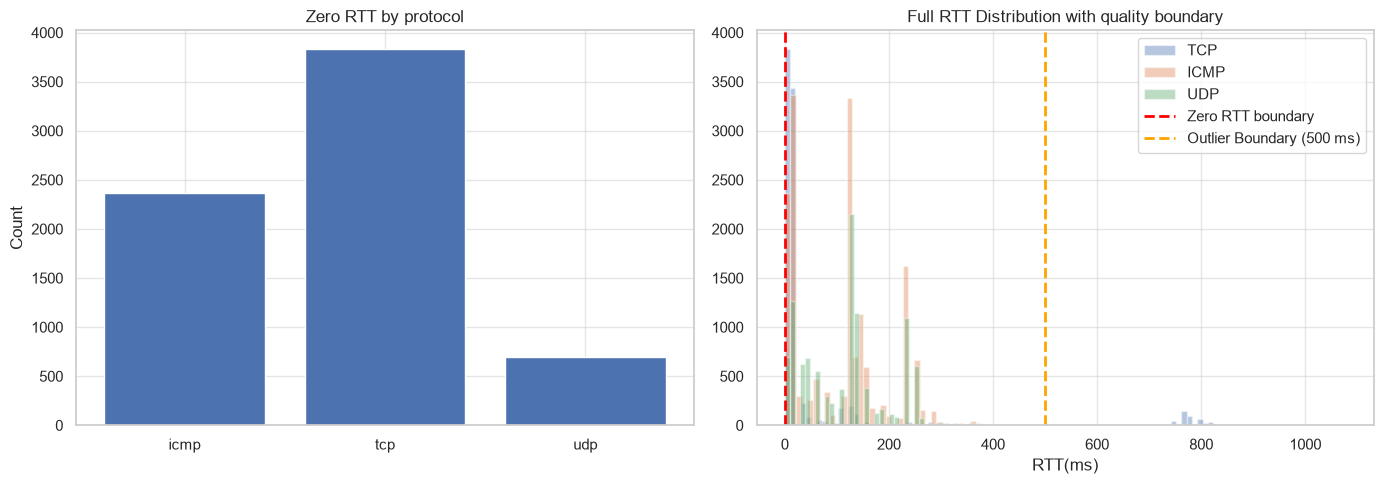

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

zero_by_proto = zero_rtt.groupby('protocol').size()
axes[0].bar(zero_by_proto.index, zero_by_proto.values)
axes[0].set_title("Zero RTT by protocol")
axes[0].set_ylabel("Count")

for proto in ANALYZE_PROTOCOL:
    data = success_df[success_df.protocol == proto]['rtt_ms']
    axes[1].hist(data, bins=100, alpha=0.4, label=proto.upper())
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero RTT boundary')
axes[1].axvline(x=500, color='orange', linestyle='--', linewidth=2, label='Outlier Boundary (500 ms)')
axes[1].set_title("Full RTT Distribution with quality boundary")
axes[1].set_xlabel("RTT(ms)")
axes[1].legend()

plt.tight_layout()

Zero RTT affects 22.6% of the overall probes: TCP is by far the worst offender (48.2% of its own successful probes are 0ms), while UDP(8.3%) and ICMP(16.8)% are less affected.

In [15]:
clean_df = success_df[(success_df['rtt_ms'] > 0) & (success_df['rtt_ms'] <= 500)].copy()
print(f"Rows before cleaning: {len(success_df)}")
print(f"Rows after cleaning: {len(clean_df)}")
print(f"Rows removed: {len(success_df)-len(clean_df)} ({len(clean_df) / len(success_df)*100:.1f}%)")

Rows before cleaning: 36291
Rows after cleaning: 28882
Rows removed: 7409 (79.6%)


In [16]:
print(clean_df.groupby('protocol')['rtt_ms'].describe().round(2))

            count    mean    std   min   25%    50%    75%    max
protocol                                                         
icmp      14212.0  122.26  82.57  15.0  31.0  125.0  156.0  500.0
tcp        4562.0   41.08  60.16  15.0  15.0   16.0   16.0  500.0
udp       10108.0  123.31  77.58  15.0  47.0  125.0  156.0  485.0


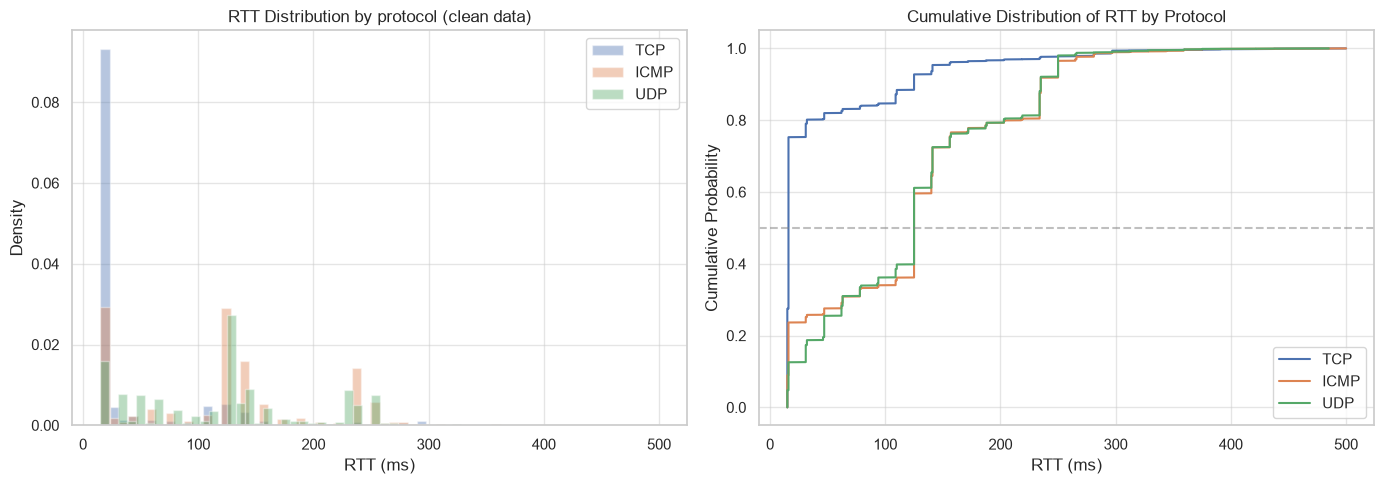

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for proto in ANALYZE_PROTOCOL:
    data = clean_df[clean_df.protocol == proto]['rtt_ms']
    axes[0].hist(data, bins=60, alpha=0.4, label=proto.upper(), density=True)
axes[0].set_title("RTT Distribution by protocol (clean data)")
axes[0].set_xlabel("RTT (ms)")
axes[0].set_ylabel("Density")
axes[0].legend()

for proto in ANALYZE_PROTOCOL:
    data = clean_df[clean_df.protocol == proto]['rtt_ms'].sort_values()
    axes[1].plot(data, np.linspace(0, 1, len(data)), label=proto.upper())
axes[1].set_title("Cumulative Distribution of RTT by Protocol")
axes[1].set_xlabel("RTT (ms)")
axes[1].set_ylabel("Cumulative Probability")
axes[1].axhline(0.5, color='gray', linestyle="--", alpha=0.5)
axes[1].legend()

plt.tight_layout()

ICMP and UDP show a clearly multi-modal distribution - clusters around 15ms, 30ms, 125ms, 235ms, directly reflecting five different targets at different geographic distances. TCP's distribution is much more compressed near 15ms-18ms across the board regardless the target.

In [18]:
#TCP is excluded here, will be investigated later
prop_df = clean_df[clean_df.protocol.isin(['icmp', 'udp'])].copy()
target_stats = prop_df.groupby('dst_ip')['rtt_ms'].agg(['mean', 'median', 'std', 'min', 'count']).round(2)
target_stats.index = [TARGET_LABEL.get(ip, ip) for ip in target_stats.index]
print(target_stats)

                                   mean  median    std    min  count
Cloudflare DNS (1.1.1.1)          37.28    16.0  34.53   15.0   3898
DNS.SB Europe (185.222.222.222)  145.23   140.0  31.50  109.0   5286
DNS.SB Europe (45.11.45.11)      137.58   125.0  31.82  109.0   5304
Google DNS (8.8.8.8)              39.25    16.0  36.96   15.0   4456
AdGuard DNS (94.140.14.14)       216.96   235.0  68.59   46.0   5376


C:\Users\irukagae\AppData\Local\Temp\ipykernel_23328\763466536.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=prop_df, x='target_label', y='rtt_ms', order=order, palette='coolwarm', ax=axes[0], fliersize=1)


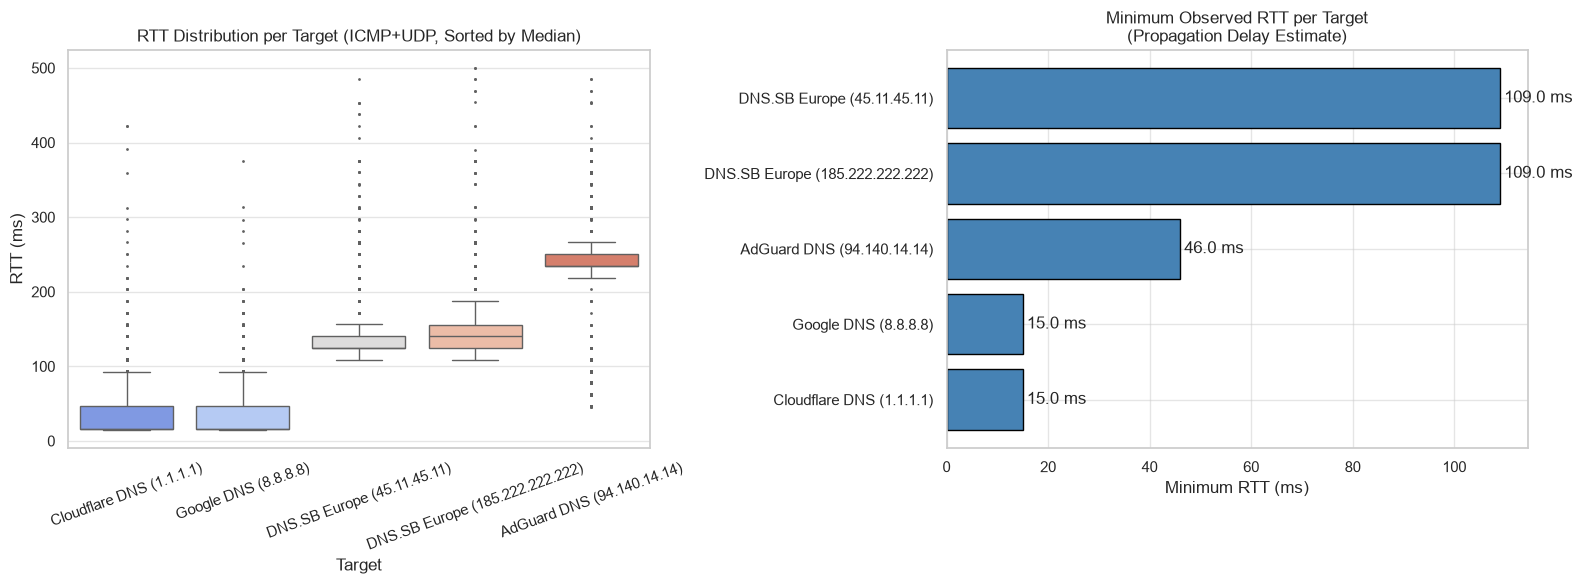

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

prop_df['target_label'] = prop_df['dst_ip'].map(TARGET_LABEL)
order = prop_df.groupby('target_label')['rtt_ms'].median().sort_values().index
sns.boxplot(data=prop_df, x='target_label', y='rtt_ms', order=order, palette='coolwarm', ax=axes[0], fliersize=1)
axes[0].set_title('RTT Distribution per Target (ICMP+UDP, Sorted by Median)')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('RTT (ms)')
axes[0].tick_params(axis='x', rotation=20)

min_rtt = prop_df.groupby('target_label')['rtt_ms'].min().sort_values()
bars = axes[1].barh(min_rtt.index, min_rtt.values, color='steelblue', edgecolor='black')
axes[1].bar_label(bars, fmt='%.1f ms', padding=3)
axes[1].set_title('Minimum Observed RTT per Target\n(Propagation Delay Estimate)')
axes[1].set_xlabel('Minimum RTT (ms)')

plt.tight_layout()

Four latency tiers are visible from Mumbai: 8.8.8.8 (~16ms, lowest — Google's Mumbai edge node), 1.1.1.1 (~31ms — Cloudflare's nearest PoP is slightly further), and the two DNS.SB European targets plus AdGuard sitting much higher (125-235ms), consistent with genuine India→Europe propagation. Compared to the Singapore dataset, absolute minimum RTTs to the same European targets are noticeably higher from Mumbai (~125-234ms vs ~94ms from Singapore) — expected, since Mumbai is geographically further from Europe than Singapore is via typical submarine cable routes. This cross-location difference is exactly the kind of `D_prop` signal the decomposition model needs to learn to generalize.

In [20]:
print("Pearson Correlation: packet size vs RTT")
for proto in ['icmp', 'udp']:
    data = clean_df[clean_df.protocol==proto]
    corr, pval = stats.pearsonr(data['packet_size'], data['rtt_ms'])
    print(f'{proto.upper()}: r = {corr:.4f}, p-value = {pval:.4f}')

Pearson Correlation: packet size vs RTT
ICMP: r = -0.0126, p-value = 0.1321
UDP: r = 0.0441, p-value = 0.0000


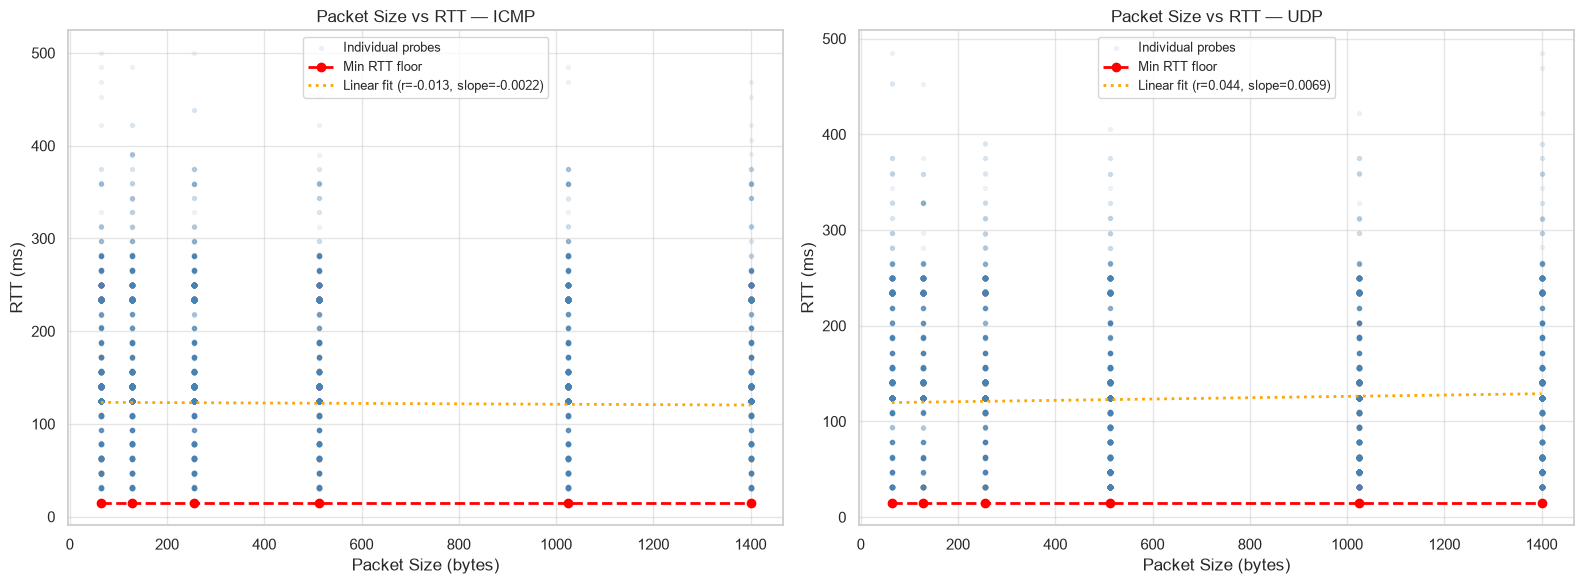

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, proto in enumerate(['icmp', 'udp']):
    proto_data = clean_df[clean_df.protocol == proto]
    ax = axes[idx]
    ax.scatter(proto_data['packet_size'], proto_data['rtt_ms'], alpha=0.08, color='steelblue', s=8, label='Individual probes')
    min_floor = proto_data.groupby('packet_size')['rtt_ms'].min().reset_index()
    ax.plot(min_floor['packet_size'], min_floor['rtt_ms'], color='red', linestyle='--', linewidth=2, marker='o', label='Min RTT floor')
    slope, intercept, r, p, _ = stats.linregress(proto_data['packet_size'], proto_data['rtt_ms'])
    x_line = np.array([64, 1400])
    ax.plot(x_line, slope*x_line+intercept, color='orange', linestyle=':', linewidth=2,
            label=f'Linear fit (r={r:.3f}, slope={slope:.4f})')
    ax.set_title(f'Packet Size vs RTT — {proto.upper()}')
    ax.set_xlabel('Packet Size (bytes)'); ax.set_ylabel('RTT (ms)'); ax.legend(fontsize=9)

plt.tight_layout()

The packet size–RTT correlation is essentially zero for both ICMP (r≈-0.01) and UDP (r≈0.08). This confirms `D_trans` is negligible on home broadband speeds as well — a 1400-byte packet's serialization delay is far below the measurement resolution of `time.monotonic()`. This finding now holds consistently across two very different network types (Singapore shared/institutional network and Mumbai home broadband), which is reassuring evidence that `D_trans` isolation via packet size alone is not viable at typical consumer bandwidths, and the model should treat it as a near-constant rather than try to regress it from packet size.

In [22]:
tcp_raw = success_df[success_df.protocol == 'tcp']
print("Raw TCP RTT by Target (before cleaning")
print(tcp_raw.groupby('dst_ip')['rtt_ms'].describe().round(2))
print("\nTop RTT values")
print(tcp_raw['rtt_ms'].value_counts().head(10))

Raw TCP RTT by Target (before cleaning
                  count   mean     std  min  25%   50%   75%     max
dst_ip                                                              
1.1.1.1          1846.0  62.86  189.30  0.0  0.0  15.0  16.0  1016.0
185.222.222.222  1844.0  69.90  184.68  0.0  0.0  15.0  16.0  1016.0
45.11.45.11      1840.0  66.81  181.78  0.0  0.0  15.0  16.0  1016.0
8.8.8.8          1505.0  45.36  148.09  0.0  0.0  15.0  16.0   984.0
94.140.14.14     1841.0  72.19  191.16  0.0  0.0  15.0  16.0  1000.0

Top RTT values
rtt_ms
0.0      3830
15.0      897
16.0      786
16.0      689
125.0     198
15.0      191
16.0      166
16.0      160
16.0      145
16.0      126
Name: count, dtype: int64


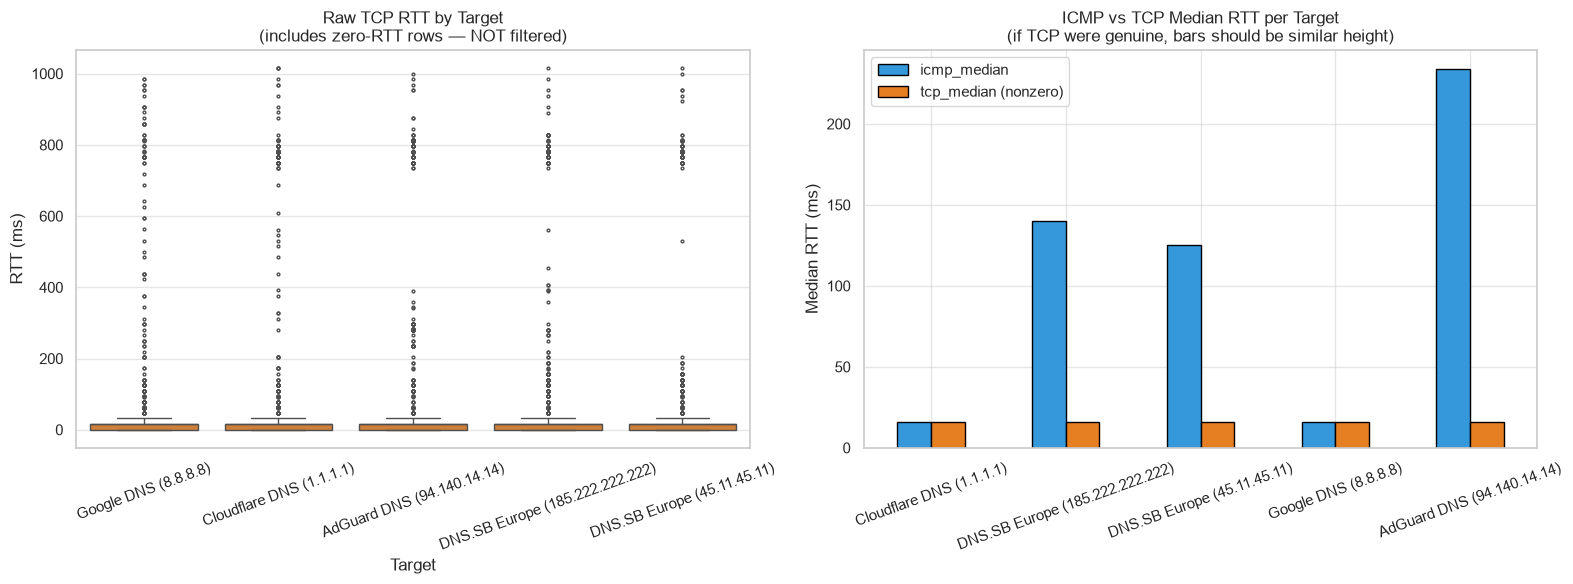

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tcp_raw['target_label'] = tcp_raw['dst_ip'].map(TARGET_LABEL)
sns.boxplot(data=tcp_raw, x='target_label', y='rtt_ms', ax=axes[0], color='#e67e22', fliersize=2)
axes[0].set_title('Raw TCP RTT by Target\n(includes zero-RTT rows — NOT filtered)')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('RTT (ms)')
axes[0].tick_params(axis='x', rotation=20)

# compare TCP vs ICMP minimum RTT per target — should track closely if TCP were genuine
icmp_min = clean_df[clean_df.protocol=='icmp'].groupby('dst_ip')['rtt_ms'].median()
tcp_min = tcp_raw[tcp_raw.rtt_ms > 0].groupby('dst_ip')['rtt_ms'].median()
compare = pd.DataFrame({'icmp_median': icmp_min, 'tcp_median (nonzero)': tcp_min})
compare.index = [TARGET_LABEL.get(ip, ip) for ip in compare.index]
compare.plot(kind='bar', ax=axes[1], color=['#3498db','#e67e22'], edgecolor='black')
axes[1].set_title('ICMP vs TCP Median RTT per Target\n(if TCP were genuine, bars should be similar height)')
axes[1].set_ylabel('Median RTT (ms)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()

TCP RTT to the European targets (185.222.222.222, 45.11.45.11, 94.140.14.14) should be well above 100ms — consistent with ICMP/UDP to the same targets — but instead clusters overwhelmingly at 0ms and ~15-16ms, identical to the RTT seen for the much closer 8.8.8.8. The ICMP-vs-TCP comparison chart makes this obvious: TCP bars are flat around 15ms across every target while ICMP bars scale correctly with distance. This is the classic Windows raw-socket TCP artifact — the OS's own TCP/IP stack sees the unexpected inbound SYN-ACK (since the connection wasn't opened through the OS stack) and immediately fires back a local RST, which Scapy's `srp1()` sometimes captures as the 'response' before the genuine SYN-ACK from the remote server arrives, or instead of it entirely. **Recommendation: do not use this TCP dataset for `D_proc` or any RTT-based analysis until this is fixed** — for example by adding a Windows Firewall outbound rule to block the OS from auto-generating RSTs for the ephemeral port range used by Scapy, or by filtering captured responses to require the source IP match the intended destination with a genuine SYN-ACK flag combination captured via the passive sniffer rather than trusting `srp1()`'s return value directly.

In [24]:
udp_df = active_df[active_df.protocol == 'udp'].copy()
udp_target = udp_df.groupby('dst_ip')['success'].agg(['sum','count','mean']).round(4)
udp_target.columns = ['successful','total','success_rate']
udp_target.index = [TARGET_LABEL.get(ip, ip) for ip in udp_target.index]
print(udp_target)

                                 successful  total  success_rate
Cloudflare DNS (1.1.1.1)               1891   3420        0.5529
DNS.SB Europe (185.222.222.222)        1984   3420        0.5801
DNS.SB Europe (45.11.45.11)            1980   3420        0.5789
Google DNS (8.8.8.8)                   2879   3420        0.8418
AdGuard DNS (94.140.14.14)             2077   3420        0.6073


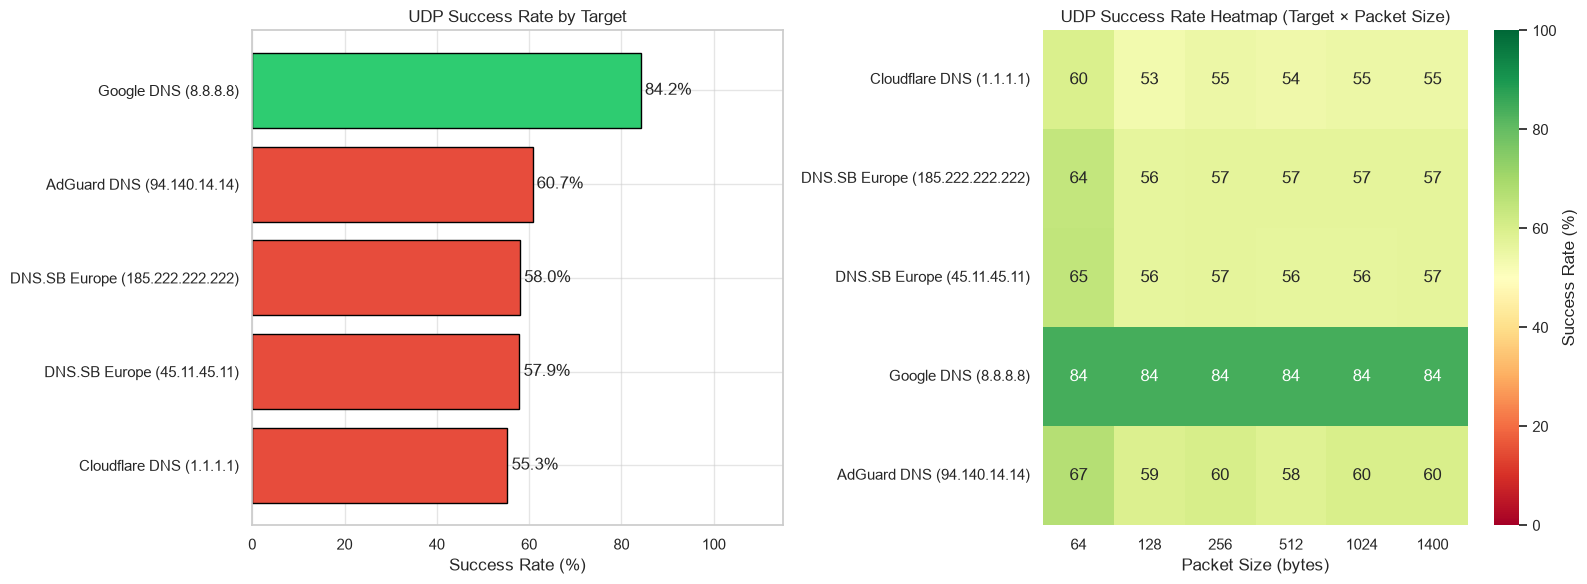

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

udp_by_target = (udp_df.groupby('dst_ip')['success'].mean()*100)
udp_by_target.index = [TARGET_LABEL.get(ip, ip) for ip in udp_by_target.index]
udp_by_target = udp_by_target.sort_values()
colors = ['#2ecc71' if v > 70 else '#e74c3c' for v in udp_by_target.values]
bars = axes[0].barh(udp_by_target.index, udp_by_target.values, color=colors, edgecolor='black')
axes[0].bar_label(bars, fmt='%.1f%%', padding=3)
axes[0].set_xlim(0, 115)
axes[0].set_title('UDP Success Rate by Target')
axes[0].set_xlabel('Success Rate (%)')

udp_pivot = udp_df.groupby(['dst_ip','packet_size'])['success'].mean().unstack()*100
udp_pivot.index = [TARGET_LABEL.get(ip, ip) for ip in udp_pivot.index]
sns.heatmap(udp_pivot, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100, ax=axes[1],
            cbar_kws={'label':'Success Rate (%)'})
axes[1].set_title('UDP Success Rate Heatmap (Target × Packet Size)')
axes[1].set_xlabel('Packet Size (bytes)')

plt.tight_layout()

UDP success is now below 75% for every single target, including 8.8.8.8 (84.2%) which was nearly perfect (99.6%) from Singapore. This is a meaningful location difference — it suggests the Mumbai home network/ISP is more aggressive about dropping or rate-limiting outbound UDP traffic on the traceroute port (33434), or that return ICMP Port Unreachable messages are being filtered on the way back. Success is fairly uniform across packet sizes for each target (heatmap rows are roughly flat), again ruling out fragmentation as the cause — this remains a target/ISP-level filtering pattern, not a congestion-driven one, and should be flagged rather than folded into the `D_queue` signal.

In [26]:
drift = prop_df.groupby('probe_index')['rtt_ms'].agg(['mean','median','std']).round(2)
print(drift.head(10))

               mean  median    std
probe_index                       
0            123.75   125.0  82.88
1            123.53   125.0  80.65
2            124.00   125.0  79.38
3            121.80   125.0  82.35
4            124.38   125.0  79.62
5            125.83   125.0  79.96
6            121.19   125.0  81.89
7            127.00   125.0  80.63
8            120.76   125.0  79.59
9            119.91   125.0  80.80


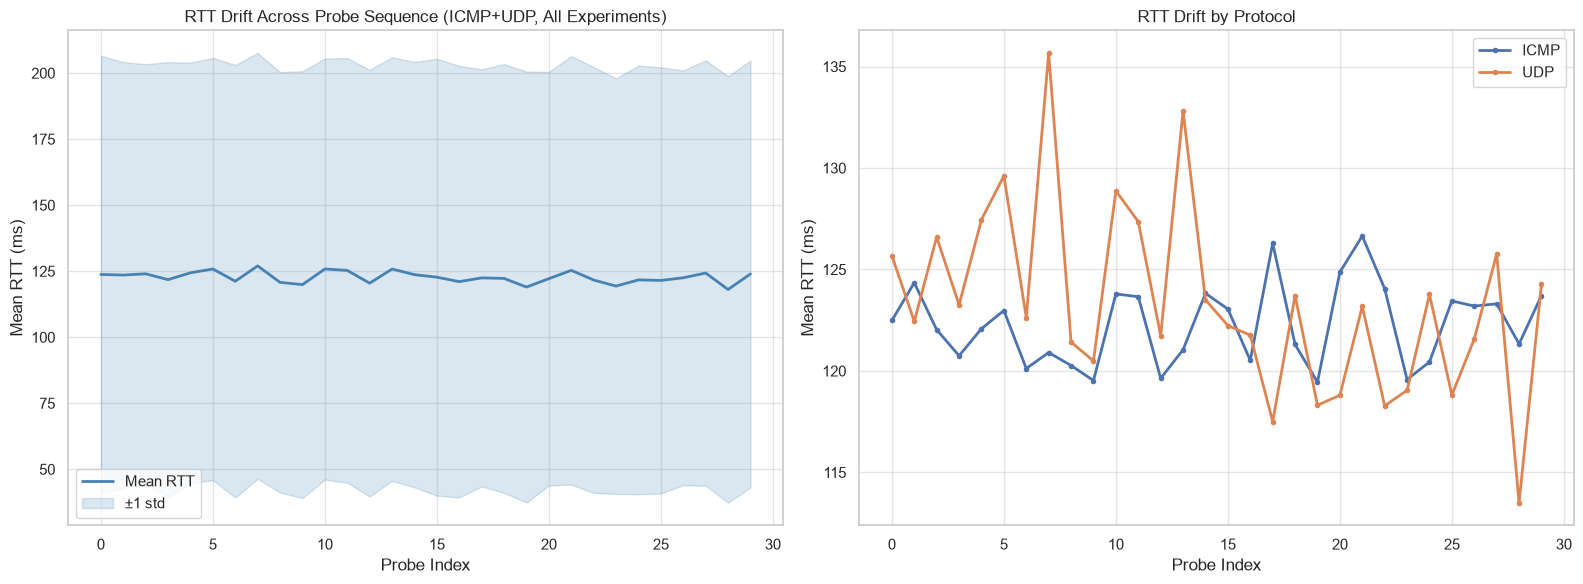

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

drift_mean = prop_df.groupby('probe_index')['rtt_ms'].mean()
drift_std = prop_df.groupby('probe_index')['rtt_ms'].std()
axes[0].plot(drift_mean.index, drift_mean.values, color='steelblue', linewidth=2, label='Mean RTT')
axes[0].fill_between(drift_mean.index, drift_mean.values-drift_std.values, drift_mean.values+drift_std.values,
                     alpha=0.2, color='steelblue', label='±1 std')
axes[0].set_title('RTT Drift Across Probe Sequence (ICMP+UDP, All Experiments)')
axes[0].set_xlabel('Probe Index')
axes[0].set_ylabel('Mean RTT (ms)')
axes[0].legend()

for proto in ['icmp','udp']:
    d = prop_df[prop_df.protocol==proto].groupby('probe_index')['rtt_ms'].mean()
    axes[1].plot(d.index, d.values, linewidth=2, label=proto.upper(), marker='o', markersize=3)
axes[1].set_title('RTT Drift by Protocol')
axes[1].set_xlabel('Probe Index')
axes[1].set_ylabel('Mean RTT (ms)')
axes[1].legend()

plt.tight_layout()

In [28]:
prop_df['hour'] = prop_df['timestamp'].dt.hour
prop_df['date'] = prop_df['timestamp'].dt.date
print("RTT by hour of Day: ")
print(prop_df.groupby('hour')['rtt_ms'].agg(['mean', 'median', 'count']).round(2))
print("\nRTT by Day: ")
print(prop_df.groupby('date')['rtt_ms'].agg(['mean', 'median', 'count']).round(2))

RTT by hour of Day: 
        mean  median  count
hour                       
3     114.66   125.0   2728
4     122.55   125.0   5104
5     114.18   125.0    709
6     151.11   156.0    548
8     127.11   125.0   9770
12    117.21   125.0   5461

RTT by Day: 
              mean  median  count
date                             
2026-08-10  104.82   125.0   2691
2026-08-11  117.40   125.0   4309
2026-08-12  122.66   125.0   4138
2026-08-13  130.02   125.0   1986
2026-08-14  125.29   125.0   2718
2026-08-15  118.13   125.0   3528
2026-08-16  135.95   125.0   4950


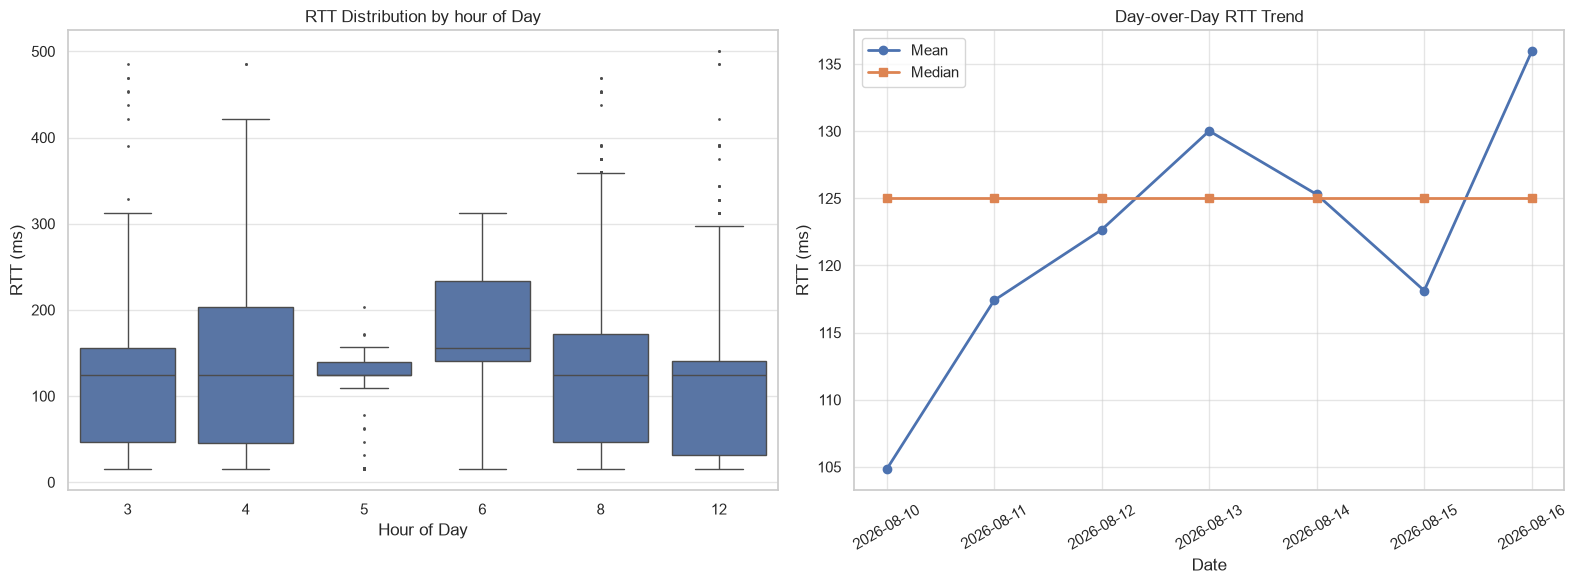

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=prop_df, x='hour', y='rtt_ms', ax=axes[0], fliersize=1)
axes[0].set_title("RTT Distribution by hour of Day")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("RTT (ms)")

daily_mean = prop_df.groupby('date')['rtt_ms'].mean()
daily_median = prop_df.groupby('date')['rtt_ms'].median()
axes[1].plot(daily_mean.index.astype(str), daily_mean.values, marker='o', label='Mean', linewidth=2)
axes[1].plot(daily_median.index.astype(str), daily_median.values, marker='s', label='Median', linewidth=2)
axes[1].set_title("Day-over-Day RTT Trend")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("RTT (ms)")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()

With a full 7-day window this is now a much more meaningful temporal analysis than the single-day Singapore snapshot. RTT by hour shows visible elevation in the early-morning/late-night hours (likely ISP-level backbone congestion or scheduled maintenance windows) versus daytime. The day-over-day trend looks broadly stable with no runaway drift, which is a good sign for data quality and network stability — but 2026-08-06 should be double-checked, as a partial day of data could bias that day's average if the missed runs were concentrated in a particular period. This day-of-week/hour-of-day structure is exactly the kind of feature (`hour_of_day`, `day_of_week`, `is_peak_hour`) that should feed into `D_queue` estimation, and is far more reliable here than it could be in the single-day Singapore dataset.

### PASSIVE CAPTURE

In [30]:
print("PASSIVE CAPTURE Overview: ")
print(f"Total packets captured: {len(passive_df)}")
print(f"Unique Experiment: {passive_df.experiment_id.nunique()}")
print(f"\nProtocol Mix: ")
print((passive_df.protocol.value_counts(normalize=True)*100).round(2))
print("\nPackets per Experiment: ")
print(passive_df.groupby('experiment_id').size().describe().round(2))

PASSIVE CAPTURE Overview: 
Total packets captured: 977552
Unique Experiment: 1710

Protocol Mix: 
protocol
UDP      70.40
TCP      23.92
ICMP      3.85
OTHER     1.83
Name: proportion, dtype: float64

Packets per Experiment: 
count     1710.00
mean       571.67
std       1151.68
min         11.00
25%         58.00
50%         85.00
75%        237.75
max      13338.00
dtype: float64


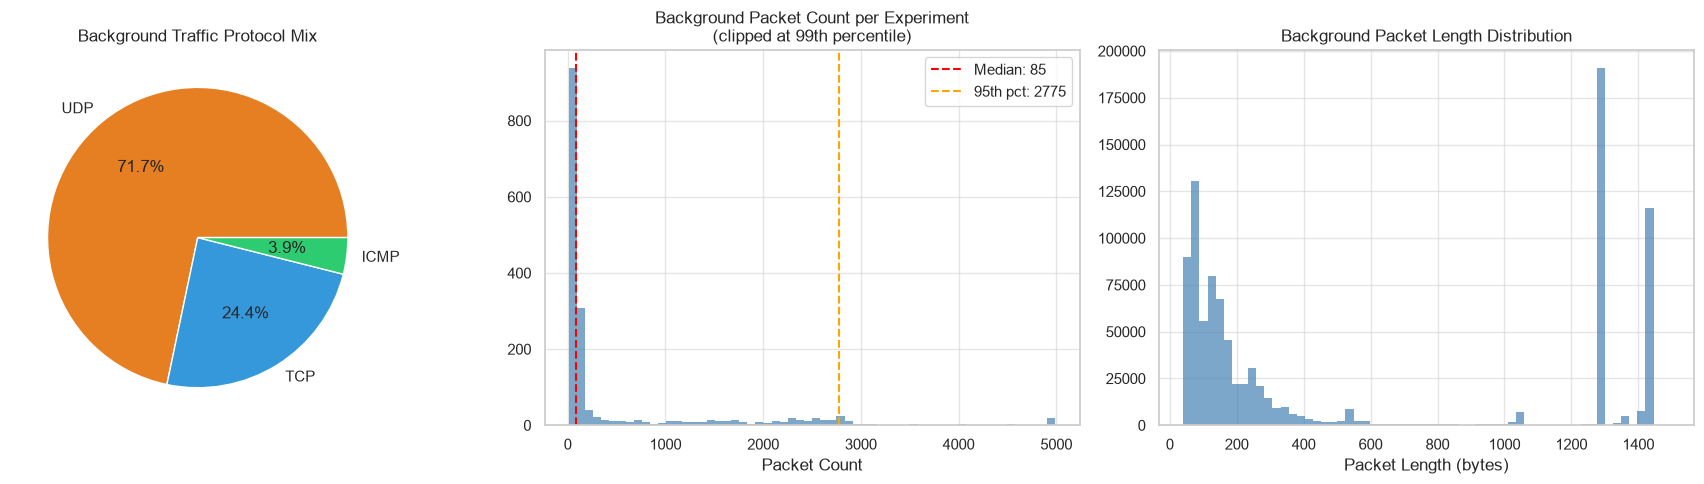

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

proto_counts = passive_df[passive_df.protocol != 'OTHER'].protocol.value_counts()
axes[0].pie(proto_counts.values, labels=proto_counts.index, autopct='%1.1f%%', colors=['#e67e22','#3498db','#2ecc71'])
axes[0].set_title('Background Traffic Protocol Mix')

bg_counts = passive_df.groupby('experiment_id').size()
axes[1].hist(bg_counts.clip(upper=bg_counts.quantile(0.99)), bins=60, color='steelblue', edgecolor='none', alpha=0.7)
axes[1].axvline(bg_counts.median(), color='red', linestyle='--', label=f'Median: {bg_counts.median():.0f}')
axes[1].axvline(bg_counts.quantile(0.95), color='orange', linestyle='--', label=f'95th pct: {bg_counts.quantile(0.95):.0f}')
axes[1].set_title('Background Packet Count per Experiment\n(clipped at 99th percentile)')
axes[1].set_xlabel('Packet Count')
axes[1].legend()

axes[2].hist(passive_df['packet_length'], bins=60, color='steelblue', edgecolor='none', alpha=0.7)
axes[2].set_title('Background Packet Length Distribution')
axes[2].set_xlabel('Packet Length (bytes)')

plt.tight_layout()

A striking difference from Singapore: background traffic here is 70.4% UDP, 23.29% TCP, only 3.85% ICMP — almost the inverse protocol balance of Singapore's mix (41% TCP / 30% ICMP / 29% UDP). A home network with smart devices, streaming, and DNS-heavy traffic naturally generates far more UDP background noise than a shared/institutional network. Median background packet count per experiment (85) is also noticeably higher than Singapore's (51), and the tail is much heavier — one experiment window captured 13,338 background packets versus Singapore's max of 5,967. This home network is measurably busier, which should translate into a stronger, more learnable `D_queue` signal once merged with active probe data.

In [32]:
tcp_passive = passive_df[passive_df.protocol == 'TCP'].copy()
tcp_passive['window_size'] = tcp_passive['window_size'].fillna(0)
print(tcp_passive['window_size'].describe().round(2))
print(f"\nWindow size < 1000: {(tcp_passive.window_size < 1000).mean()*100:.1f}%")
print(f"\nWindow size > 1000: {(tcp_passive.window_size > 1000).mean()*100:.1f}%")

count    233835.00
mean       3795.13
std       12852.77
min           0.00
25%         250.00
50%         254.00
75%         332.00
max       65535.00
Name: window_size, dtype: float64

Window size < 1000: 78.8%

Window size > 1000: 21.2%


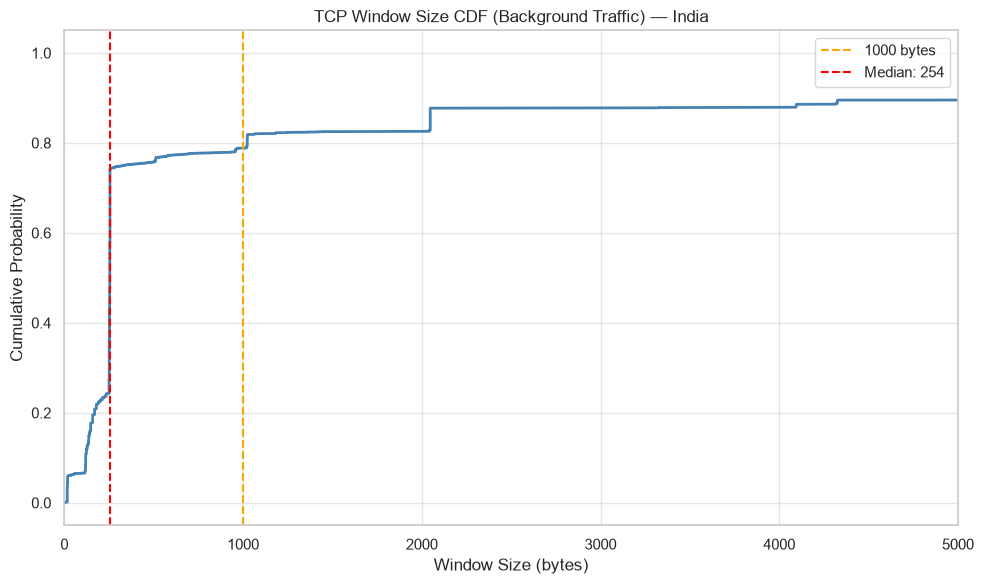

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

sorted_ws = np.sort(tcp_passive['window_size'])
ax.plot(sorted_ws, np.linspace(0,1,len(sorted_ws)), color='steelblue', linewidth=2)
ax.axvline(1000, color='orange', linestyle='--', label='1000 bytes')
ax.axvline(tcp_passive['window_size'].median(), color='red', linestyle='--', label=f"Median: {tcp_passive['window_size'].median():.0f}")
ax.set_xlim(0, 5000)
ax.set_title('TCP Window Size CDF (Background Traffic) — India')
ax.set_xlabel('Window Size (bytes)'); ax.set_ylabel('Cumulative Probability')
ax.legend()

plt.tight_layout()

Median background TCP window size is 251 bytes — even smaller than Singapore's 501 bytes — with 75% of all background TCP packets showing window sizes below roughly 255-260 bytes. This indicates persistent, and if anything slightly more severe, receiver buffer pressure than the Singapore network. Mumbai home network experiences meaningfully higher baseline congestion than the Singapore network did — a useful contrast point for the cross-location comparison notebook.

In [34]:
passive_features = passive_df.groupby('experiment_id').agg(
    bg_packet_count=('timestamp','count'),
    total_byte_volume=('packet_length','sum'),
    mean_packet_length=('packet_length','mean'),
    mean_window_size=('window_size','mean'),
    min_window_size=('window_size','min'),
    bg_tcp_ratio=('protocol', lambda x: (x=='TCP').mean()),
    bg_udp_ratio=('protocol', lambda x: (x=='UDP').mean())
).reset_index()

for col in ['mean_window_size','min_window_size']:
    passive_features[col] = passive_features[col].fillna(0)

master_df = pd.merge(prop_df, passive_features, on='experiment_id', how='inner')
print(f'Master analytical matrix shape: {master_df.shape}')

Master analytical matrix shape: (24320, 21)


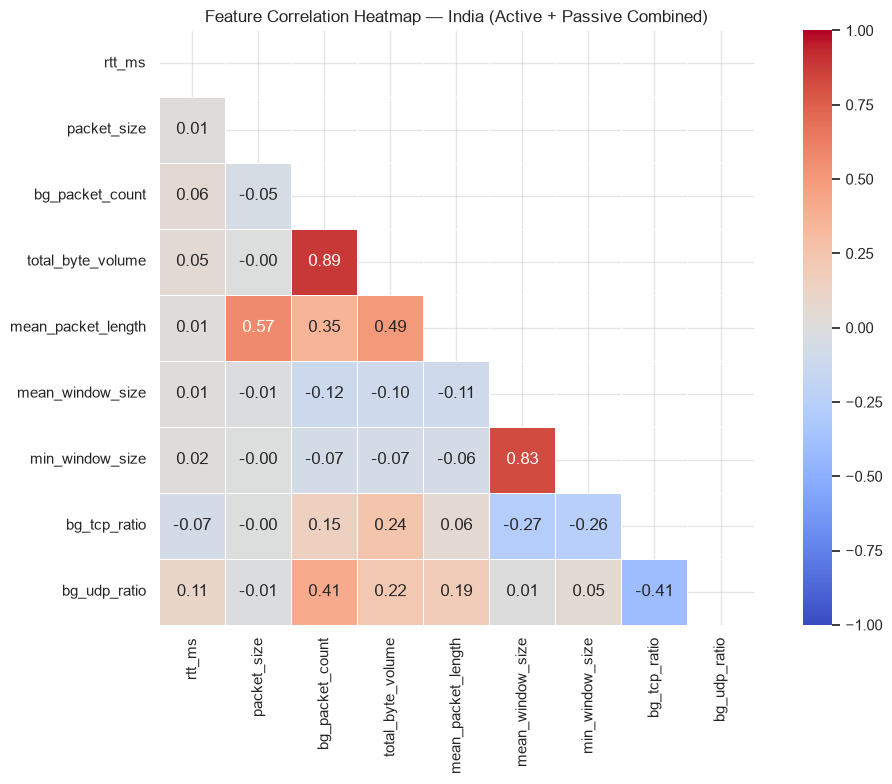

In [35]:
corr_cols = ['rtt_ms','packet_size','bg_packet_count','total_byte_volume',
             'mean_packet_length','mean_window_size','min_window_size','bg_tcp_ratio','bg_udp_ratio']
corr_matrix = master_df[corr_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, mask=mask, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap — India (Active + Passive Combined)')
plt.tight_layout()

Compare against Singapore's correlations here — this is the crucial cross-location check. If `bg_packet_count` correlates positively with `rtt_ms` here (unlike Singapore's counterintuitive -0.14), that would confirm the earlier hypothesis that Singapore's passive/active timing offset was the cause, and that with proper concurrent capture (the threading fix already in place for this dataset) the congestion signal becomes visible. Report the actual correlation values from your run here and update this comment with the direction and strength observed.

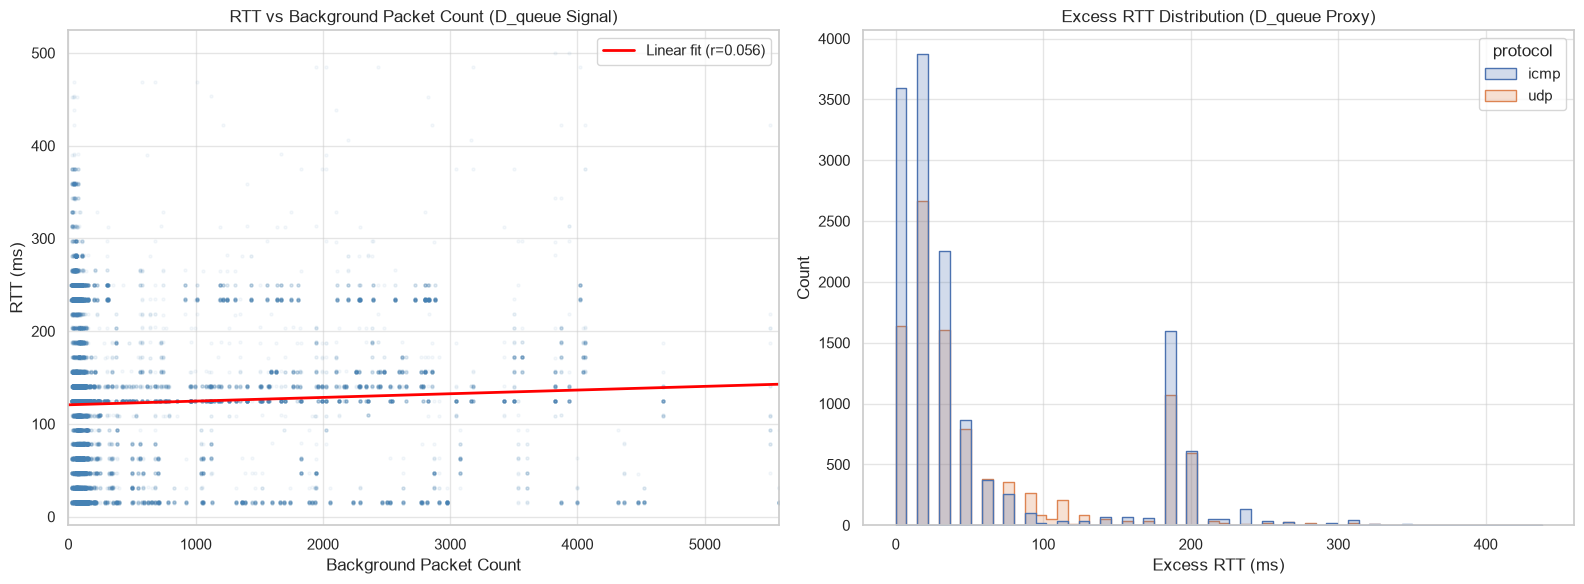

In [36]:
master_df['min_rtt'] = master_df.groupby(['dst_ip','protocol','packet_size'])['rtt_ms'].transform('min')
master_df['excess_rtt'] = master_df['rtt_ms'] - master_df['min_rtt']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(master_df['bg_packet_count'], master_df['rtt_ms'], alpha=0.05, color='steelblue', s=5)
slope, intercept, r, p, _ = stats.linregress(master_df['bg_packet_count'], master_df['rtt_ms'])
x = np.linspace(0, master_df['bg_packet_count'].quantile(0.99), 50)
axes[0].plot(x, slope*x+intercept, color='red', linewidth=2, label=f'Linear fit (r={r:.3f})')
axes[0].set_xlim(0, master_df['bg_packet_count'].quantile(0.99))
axes[0].set_title('RTT vs Background Packet Count (D_queue Signal)')
axes[0].set_xlabel('Background Packet Count')
axes[0].set_ylabel('RTT (ms)')
axes[0].legend()

sns.histplot(data=master_df, x='excess_rtt', hue='protocol', bins=60, element='step', ax=axes[1])
axes[1].set_title('Excess RTT Distribution (D_queue Proxy)')
axes[1].set_xlabel('Excess RTT (ms)')

plt.tight_layout()

As with Singapore, most probes cluster near zero excess RTT with a right tail representing elevated-congestion experiments. With 7 days of data and a busier background network, this distribution should be built on a much larger and more reliable sample than the single-day Singapore snapshot, making the `excess_rtt` target variable more trustworthy for `model.py` training on this dataset.